In [1]:
import pandas as pd

# **LOAD DATASET**

In [2]:
df = pd.read_csv(r"dataset/AAPL.csv",
                 delimiter = ",")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600
...,...,...,...,...,...,...,...
10463,2022-06-13,132.869995,135.199997,131.440002,131.880005,131.880005,122207100
10464,2022-06-14,133.130005,133.889999,131.479996,132.759995,132.759995,84784300
10465,2022-06-15,134.289993,137.339996,132.160004,135.429993,135.429993,91533000
10466,2022-06-16,132.080002,132.389999,129.039993,130.059998,130.059998,108123900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10468 non-null  datetime64[ns]
 1   Open       10468 non-null  float64       
 2   High       10468 non-null  float64       
 3   Low        10468 non-null  float64       
 4   Close      10468 non-null  float64       
 5   Adj Close  10468 non-null  float64       
 6   Volume     10468 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 572.6 KB


In [ ]:
df.set_index(
    keys = "Date",
    inplace = True
)
df.sort_index(inplace = True)

# **PREPROCESSING**

## Scale Numerical Features

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(
    feature_range = (0, 1)
)

In [10]:
scaled_values = scaler.fit_transform(df[df.columns])
scaled_values

array([[4.30950014e-04, 4.33270567e-04, 4.42511906e-04, 4.35483696e-04,
        3.40815838e-04, 6.31981003e-02],
       [3.97331936e-04, 3.96658463e-04, 4.05118893e-04, 3.98684579e-04,
        3.12018225e-04, 2.36989104e-02],
       [3.48427437e-04, 3.47836857e-04, 3.55255959e-04, 3.49613594e-04,
        2.73615897e-04, 1.42459064e-02],
       ...,
       [7.35239774e-01, 7.50670228e-01, 7.37757535e-01, 7.44010911e-01,
        7.46069029e-01, 1.23332565e-02],
       [7.23135563e-01, 7.23604845e-01, 7.20334206e-01, 7.14499102e-01,
        7.16477939e-01, 1.45687326e-02],
       [7.12126738e-01, 7.27377614e-01, 7.24634207e-01, 7.22742631e-01,
        7.24743614e-01, 1.80712734e-02]])

In [ ]:
scaled_values.shape # 6 columns, date column is now index

(10468, 6)

In [ ]:
df_scaled = pd.DataFrame(
    data = scaled_values,
    columns = df.columns,
    index = df.index
)
df_scaled

In [15]:
df_scaled.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10468.000000,10468.000000,10468.000000,10468.000000,10468.000000,10468.000000
mean,0.080558,0.081316,0.081227,0.080866,0.077654,0.044579
std,0.174795,0.176549,0.176153,0.175474,0.174336,0.045656
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.001281,0.001310,0.001271,0.001288,0.001086,0.016678
50%,0.002325,0.002368,0.002328,0.002343,0.001951,0.029395
75%,0.081628,0.082057,0.081775,0.081627,0.070517,0.055322
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


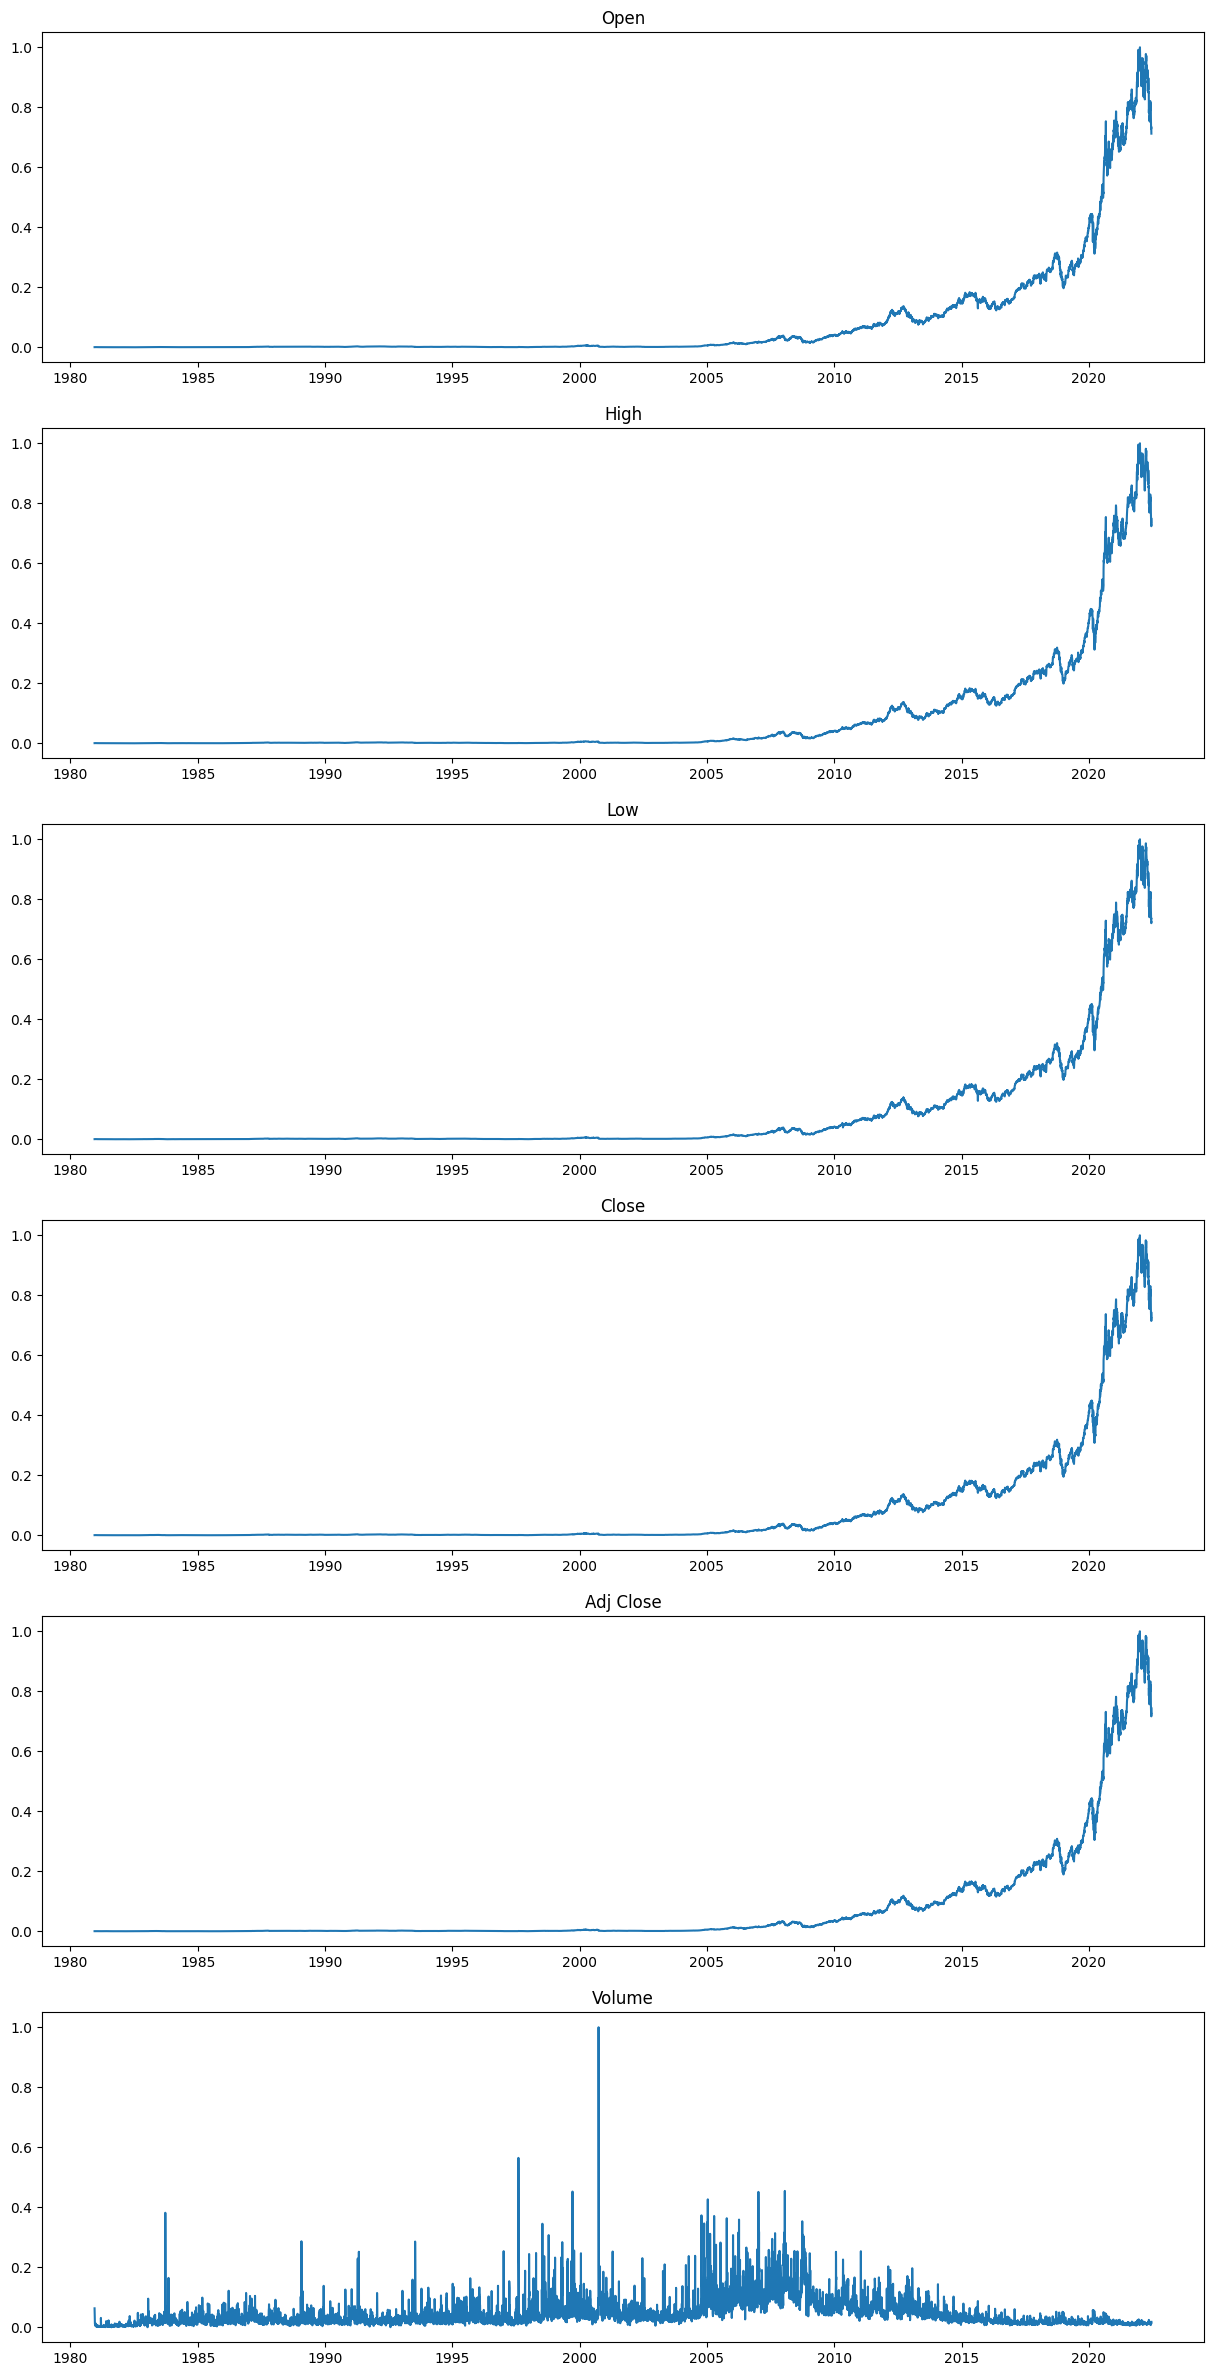

In [17]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15, 30)
figure, axes = plt.subplots(6)

for ax, col in zip(axes, df_scaled.columns):
    ax.plot(df_scaled[col])
    ax.set_title(col)
    ax.axes.xaxis.set_visible = False

## Create Sliding Window

In [22]:
import numpy as np

def create_sequence(data, window_size):
    x = []
    y = []
    for i in range(window_size, len(data)):
        x.append(data.iloc[i - window_size:i].values)
        y.append(data.iloc[i].values)
    return np.array(x), np.array(y)

In [23]:
x, y = create_sequence(
    df_scaled, 
    window_size = 60
)

In [24]:
x.shape, y.shape

((10408, 60, 6), (10408, 6))

# TRAIN / TEST SPLIT

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.2,
                                                    train_size = 0.8, 
                                                    random_state = 42,
                                                    shuffle = True)

In [60]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8326, 60, 6), (2082, 60, 6), (8326, 6), (2082, 6))

In [49]:
import torch

X_train_torch = torch.tensor(X_train, 
                             dtype = torch.float32)
y_train_torch = torch.tensor(y_train, 
                             dtype = torch.float32)

In [50]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_torch, 
                              y_train_torch)
train_loader = DataLoader(dataset = train_dataset, 
                          batch_size = 3, 
                          shuffle = True)

In [51]:
import torch

X_test_torch = torch.tensor(X_test, 
                            dtype = torch.float32)
y_test_torch = torch.tensor(y_test, 
                            dtype = torch.float32)

In [52]:
from torch.utils.data import DataLoader, TensorDataset

test_dataset = TensorDataset(X_test_torch, 
                             y_test_torch)
test_loader = DataLoader(test_dataset, 
                         batch_size = 3, 
                         shuffle = False)

# **MODEL BUILDING and TRAINING**

## Using Keras

### implement EARLY STOPPING

In [43]:
from tensorflow.keras.callbacks import EarlyStopping # pyright: ignore[reportMissingImports]

early_stopping = EarlyStopping(
    monitor = "val_loss", # what to monitor for early stopping
    patience = 10, # if "val_loss" aint changing in 10 consecutive epochs, training stops
    restore_best_weights = True
)

### implement CHECKPOINT

In [78]:
from tensorflow.keras.callbacks import ModelCheckpoint # pyright: ignore[reportMissingImports]

checkpoint_cb = ModelCheckpoint(
    "my_keras_model.h5",
    save_best_only = True
)

### implement CUSTOM CALLBACK

In [77]:
from tensorflow import keras

class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

### implement MODEL

In [79]:
from tensorflow import keras

model_keras = keras.Sequential([
    keras.layers.LSTM(
        units = 50, 
        return_sequences = True, 
        input_shape = (X_train.shape[1], X_train.shape[2])
    ),
    keras.layers.Dropout(
        rate = 0.3
    ),

    keras.layers.LSTM(
        units = 50, 
        return_sequences = True
    ),
    keras.layers.Dropout(
        rate = 0.3
    ),

    keras.layers.LSTM(
        units = 50, 
        return_sequences = False
    ),
    keras.layers.Dropout(
        rate = 0.3
    ),

    keras.layers.Dense(
        y_train.shape[1]
    )
    
])

#### .summary()

In [80]:
model_keras.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 50)            11400     
                                                                 
 dropout (Dropout)           (None, 60, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 60, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 60, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 6)                 3

### choose OPTIMIZER

In [45]:
optimizer = keras.optimizers.Adam(learning_rate = 0.001)

### choose LOSS FUNCTION

In [46]:
loss = keras.losses.MeanSquaredError()

### BACKPROPAGATION

#### .compile()

In [47]:
model_keras.compile(
    optimizer = optimizer,
    loss = loss,
    metrics = ["RootMeanSquaredError"]
)

#### .fit()

In [ ]:
LSTM_model = model_keras.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 10,
    batch_size = 3,
    callbacks = [early_stopping, checkpoint_cb, PrintValTrainRatioCallback()]
)

In [73]:
LSTM_model.history

{'loss': [0.0021465271711349487,
  0.0014082626439630985,
  0.0011356361210346222,
  0.0009190983837470412,
  0.0009825598681345582,
  0.0008590042125433683,
  0.0008704701904207468,
  0.0008040202665142715,
  0.0008117776014842093,
  0.0007882199133746326],
 'root_mean_squared_error': [0.04633067548274994,
  0.03752681985497475,
  0.03369920700788498,
  0.03031662106513977,
  0.03134578838944435,
  0.02930878847837448,
  0.029503751546144485,
  0.028355242684483528,
  0.028491731733083725,
  0.02807525359094143],
 'val_loss': [0.000406579056289047,
  0.0007139612571336329,
  0.00038828051765449345,
  0.00044222106225788593,
  0.00043805118184536695,
  0.0010747512569651008,
  0.0009928446961566806,
  0.0004587968869600445,
  0.00031250767642632127,
  0.0007486150716431439],
 'val_root_mean_squared_error': [0.020163802430033684,
  0.026720065623521805,
  0.01970483735203743,
  0.021029040217399597,
  0.020929664373397827,
  0.032783396542072296,
  0.03150941804051399,
  0.0214195530861

## Using Pytorch

### implement EARLY STOPPING

In [ ]:
class EarlyStopping:
    def __init__(self, patience = 10, min_delta = 0):
        self.patience = patience 
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

early_stopping = EarlyStopping(
    patience = 10
)

### implement MODEL

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_dim, 
            hidden_dim = 50, 
            output_dim = 1, 
            dropout = 0.3
        ):
        super(LSTMModel, self).__init__()
        
        self.lstm1 = nn.LSTM(
            input_dim, 
            hidden_dim, 
            batch_first = True
        )
        self.dropout1 = nn.Dropout(dropout)
        
        self.lstm2 = nn.LSTM(
            hidden_dim, 
            hidden_dim, 
            batch_first = True
        )
        self.dropout2 = nn.Dropout(dropout)
        
        self.lstm3 = nn.LSTM(
            hidden_dim, 
            hidden_dim, 
            batch_first = True
        )
        self.dropout3 = nn.Dropout(dropout)
        
        self.fc = nn.Linear(
            hidden_dim, 
            output_dim
        )

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        
        x, _ = self.lstm3(x)
        x = self.dropout3(x)
        
        # Take only the last time step output
        x = x[:, -1, :]
        return self.fc(x)
    
model_torch = LSTMModel(
    input_dim = X_train.shape[2], 
    output_dim = y_train.shape[1]
)

### choose OPTIMIZER

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model_torch.parameters(), lr = 0.001)

### choose LOSS FUNCTION

In [28]:
criterion = nn.MSELoss()

### BACKPROPAGATION

In [ ]:
for epoch in range(10):
    total_loss = 0
    
    model_torch.train()
    for X_batch, y_batch in train_loader:
        
        # 1. Forward pass
        output = model_torch(X_batch)

        # 2. Compute loss
        loss = criterion(output, y_batch)

        # 3. Backward pass and optimization
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
    
    val_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/10] - Val Loss: {val_loss:.4f}")

    early_stopping(val_loss)
    if early_stopping.should_stop:
        print("Early stopping triggered.")
        break

# **MODEL SAVING**

## Using Keras

In [ ]:
model_keras.save(
    filepath = f'models/LSTM_time_series.keras',
    overwrite = True,
    include_optimizer = True
)

## Using Pytorch

In [ ]:
torch.save(
    obj = model_torch.state_dict(), 
    f = "models/LSTM_time_series.pt"
)

# **MODEL LOADING**

## Using Keras

In [61]:
from tensorflow import keras

loaded_keras_model = keras.models.load_model(filepath = 'models/LSTM_time_series.keras')
loaded_keras_model

In [63]:
keras_predictions = loaded_keras_model.predict(X_test)
keras_predictions

66/66 [==============================] - 1s 20ms/step


array([[0.0021221 , 0.00202328, 0.0021528 , 0.0018499 , 0.00071819,
        0.03180666],
       [0.00294225, 0.00283068, 0.00288978, 0.00257687, 0.00130554,
        0.03865645],
       [0.2472812 , 0.2486186 , 0.24986026, 0.24872226, 0.2404764 ,
        0.01576202],
       ...,
       [0.15186867, 0.15264189, 0.15355563, 0.15269509, 0.14657618,
        0.02121963],
       [0.00178973, 0.00171939, 0.00187038, 0.00158565, 0.00068232,
        0.01630229],
       [0.00394779, 0.0037901 , 0.00376609, 0.00342389, 0.00146082,
        0.08481891]], dtype=float32)

In [64]:
keras_predictions_inverse_scaled = scaler.inverse_transform(keras_predictions)
keras_predictions_inverse_scaled

array([[4.37119484e-01, 4.19703305e-01, 4.34610903e-01, 3.85717303e-01,
        1.68661594e-01, 2.36057632e+08],
       [5.86861849e-01, 5.67369819e-01, 5.66582859e-01, 5.17997086e-01,
        2.75248915e-01, 2.86894304e+08],
       [4.51983490e+01, 4.55196037e+01, 4.47918053e+01, 4.53068275e+01,
        4.36783943e+01, 1.16980080e+08],
       ...,
       [2.77778988e+01, 2.79663925e+01, 2.75464497e+01, 2.78336411e+01,
        2.66380024e+01, 1.57484496e+08],
       [3.76435190e-01, 3.64123970e-01, 3.84037405e-01, 3.37634176e-01,
        1.62152663e-01, 1.20989736e+08],
       [7.70454705e-01, 7.42838144e-01, 7.23504007e-01, 6.72121465e-01,
        3.03429008e-01, 6.29495488e+08]], dtype=float32)

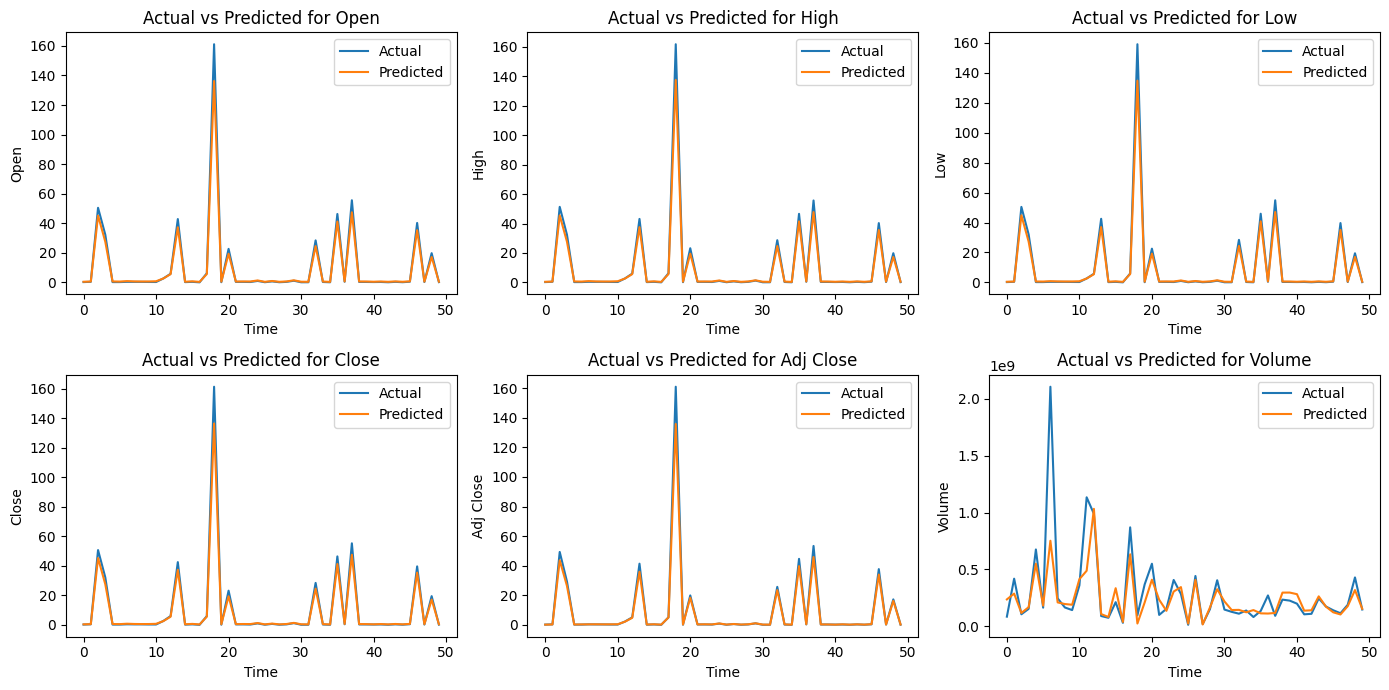

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 7))

for i, col in enumerate(df_scaled.columns):
    plt.subplot(2, 3, i + 1)
    plt.plot(scaler.inverse_transform(y_test)[:50, i], label = 'Actual')
    plt.plot(keras_predictions_inverse_scaled[:50, i], label = 'Predicted')
    plt.title(f'Actual vs Predicted for {col}')
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()

## Using Pytorch

In [68]:
state_dict = torch.load(
    f = "models/LSTM_time_series.pt",
    weights_only = True
)

loaded_torch_model = LSTMModel(
    input_dim = X_train.shape[2], 
    output_dim = y_train.shape[1]
)

loaded_torch_model.load_state_dict(state_dict)

<All keys matched successfully>

In [74]:
loaded_torch_model.eval()
with torch.no_grad():
    torch_predictions = []
    for X_batch, y_batch in test_loader:
        y_pred = loaded_torch_model(X_batch)
        torch_predictions.append(y_pred)

torch_predictions = torch.cat(torch_predictions, dim = 0)
torch_predictions

tensor([[-0.0009, -0.0007, -0.0008, -0.0008, -0.0025,  0.0280],
        [-0.0014, -0.0013, -0.0014, -0.0013, -0.0034,  0.0342],
        [ 0.2724,  0.2753,  0.2749,  0.2729,  0.2647,  0.0216],
        ...,
        [ 0.1726,  0.1744,  0.1742,  0.1729,  0.1656,  0.0259],
        [-0.0027, -0.0026, -0.0027, -0.0026, -0.0041,  0.0192],
        [ 0.0049,  0.0052,  0.0049,  0.0050,  0.0022,  0.0687]])

In [75]:
torch_predictions_inverse_scaled = scaler.inverse_transform(torch_predictions.numpy())
torch_predictions_inverse_scaled

array([[-1.0827470e-01, -7.9521373e-02, -9.5066048e-02, -8.8434279e-02,
        -4.1340294e-01,  2.0782093e+08],
       [-2.0523219e-01, -1.7917117e-01, -1.9320048e-01, -1.8744345e-01,
        -5.7886940e-01,  2.5382067e+08],
       [ 4.9791363e+01,  5.0397255e+01,  4.9277534e+01,  4.9707897e+01,
         4.8072208e+01,  1.6017090e+08],
       ...,
       [ 3.1558733e+01,  3.1940153e+01,  3.1246805e+01,  3.1512358e+01,
         3.0096437e+01,  1.9242533e+08],
       [-4.4674918e-01, -4.2311493e-01, -4.2780706e-01, -4.2564106e-01,
        -7.1132475e-01,  1.4239691e+08],
       [ 9.4532371e-01,  9.9188226e-01,  9.3130952e-01,  9.5762265e-01,
         4.3318021e-01,  5.0955830e+08]], dtype=float32)

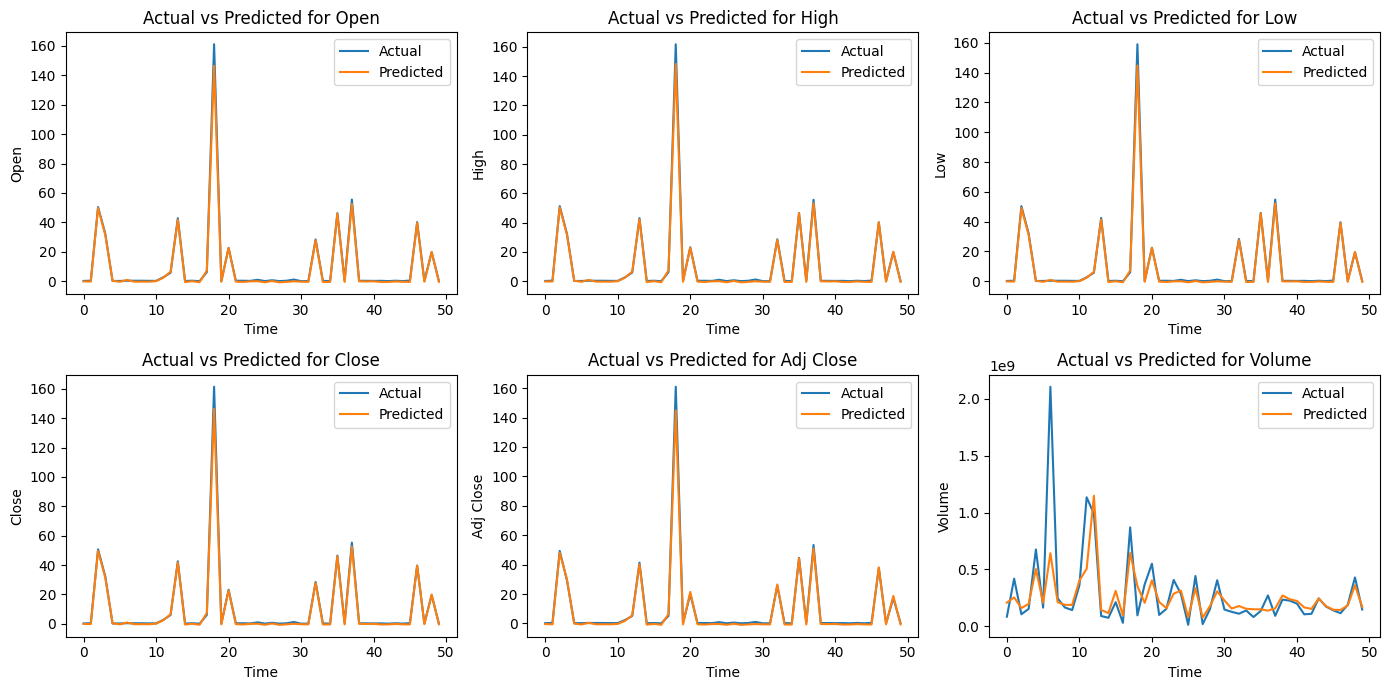

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 7))

for i, col in enumerate(df_scaled.columns):
    plt.subplot(2, 3, i + 1)
    plt.plot(scaler.inverse_transform(y_test)[:50, i], label = 'Actual')
    plt.plot(torch_predictions_inverse_scaled[:50, i], label = 'Predicted')
    plt.title(f'Actual vs Predicted for {col}')
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()

# **MODEL TESTING**

## Using Keras

In [67]:
scores = loaded_keras_model.evaluate(
    X_test, 
    y_test
)
print(f"RMSE: {scores[1]}")

66/66 [==============================] - 1s 22ms/step - loss: 5.8543e-04 - root_mean_squared_error: 0.0242
RMSE: 0.024195639416575432


## Using Pytorch

In [58]:
import torch.nn.functional as F

model_torch.eval()
total_loss = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model_torch(X_batch)
        total_loss += F.mse_loss(y_pred, y_batch, reduction = 'sum')

mse = total_loss / len(test_loader.dataset)
rmse = torch.sqrt(torch.tensor(mse.clone().detach().numpy()))
print(f"Test MSE: {mse.item():.6f}")
print(f"Test RMSE: {rmse.item():.6f}")


Test MSE: 0.001481
Test RMSE: 0.038489
